Following the linear regression analysis, we use a random forest to see whether a non-linear model can improve prediction of G3 and to compare which variables are most useful for prediction.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

df = pd.read_csv("1-data.csv")

print(df.shape)
print("Missing values:", df.isnull().sum().sum())

(649, 33)
Missing values: 0


In [2]:
def test_rf(columns_to_remove, model=None):
    X = df.drop(columns=columns_to_remove)
    y = df["G3"]

    X = pd.get_dummies(X, drop_first=True)

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )

    if model is None:
        model = RandomForestRegressor(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        )

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    results = {
        "Train R²": r2_score(y_train, train_pred),
        "Test R²": r2_score(y_test, test_pred),
        "MAE": mean_absolute_error(y_test, test_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, test_pred))
    }

    for name, value in results.items():
        print(f"{name}: {value:.3f}")

    return model, X_train, X_test, y_train, y_test, test_pred, results

First we fit a model using all 32 predictors:

In [3]:
rf_all, X_train_all, X_test_all, y_train_all, y_test_all, pred_all, results_all = test_rf(
    ["G3"]
)

importance_all = pd.Series(
    rf_all.feature_importances_,
    index=X_train_all.columns
).sort_values(ascending=False)

print("Top predictors using all variables:")
print(importance_all.head(15))

Train R²: 0.978
Test R²: 0.843
MAE: 0.737
RMSE: 1.236
Top predictors using all variables:
G2              0.827750
absences        0.035207
G1              0.018652
age             0.008780
freetime        0.007537
Dalc            0.007343
Medu            0.006484
famrel          0.006302
school_MS       0.006217
goout           0.005875
reason_other    0.005778
health          0.005689
traveltime      0.005173
Walc            0.005083
Fedu            0.004517
dtype: float64


G2 is clearly the strongest predictor when we include everything. G1 and failures also give information about previous academic performance, so we remove all three to see how well the other variables work on their own. R² measures how much of the variation in final grades is explained by the model. MAE is the average absolute prediction error, while RMSE gives more weight to larger errors.

Train R²: 0.898
Test R²: 0.142
MAE: 2.160
RMSE: 2.892
Top predictors without previous academic performance:
school_MS        0.094262
absences         0.089509
higher_yes       0.075193
Dalc             0.051464
Fedu             0.049935
Walc             0.049377
age              0.049332
health           0.047415
freetime         0.042649
Medu             0.040222
goout            0.039683
studytime        0.037138
famrel           0.035645
traveltime       0.024808
schoolsup_yes    0.024056
dtype: float64


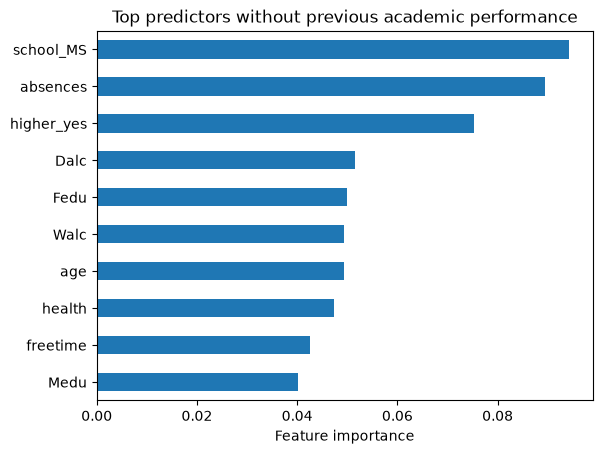

In [4]:
rf_basic, X_train, X_test, y_train, y_test, y_pred, results_basic = test_rf(
    ["G1", "G2", "G3", "failures"]
)

importance_basic = pd.Series(
    rf_basic.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print("Top predictors without previous academic performance:")
print(importance_basic.head(15))

importance_basic.head(10).sort_values().plot(kind="barh")
plt.xlabel("Feature importance")
plt.title("Top predictors without previous academic performance")
plt.show()

To judge whether our random forest without previous academic performance is actually useful we will compare it with a simple baseline.

In [5]:
baseline_pred = np.repeat(y_train.mean(), len(y_test))

baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_r2 = r2_score(y_test, baseline_pred)
print("Baseline MAE:", round(baseline_mae, 3))
print("Baseline RMSE:", round(baseline_rmse, 3))
print("Baseline R²:", round(baseline_r2, 3))

Baseline MAE: 2.395
Baseline RMSE: 3.173
Baseline R²: -0.032


The random forest does better than the baseline, with lower MAE and RMSE. However, the test R² is only 0.142, so the remaining variables do not predict final grade particularly well.

There is a big difference between the training and test R², which suggests the model is overfitting. We use 5-fold cross-validation to see how well it performs across different splits of the training data.

In [6]:
cv_split = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    rf_basic,
    X_train,
    y_train,
    cv=cv_split,
    scoring="r2",
    n_jobs=-1
)

print("CV R²:", np.round(cv_scores, 3))
print("Mean CV R²:", round(cv_scores.mean(), 3))
print("Standard deviation:", round(cv_scores.std(), 3))

CV R²: [ 0.215 -0.104  0.325  0.172  0.327]
Mean CV R²: 0.187
Standard deviation: 0.157


The mean CV R² is 0.187, which is fairly close to the test R². However, the scores vary quite a lot between folds and one is negative, so the model is not very consistent across different subsets of the data.

Next we tune some of the random forest parameters using the training data. We tune max_depth, min_samples_leaf and max_features to see whether changing tree complexity improves performance.

In [7]:
cv_split = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

param_grid = {
    "max_depth": [3, 5, None],
    "min_samples_leaf": [1, 3, 5],
    "max_features": ["sqrt", 1.0]
}

grid = GridSearchCV(
    RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),
    param_grid=param_grid,
    cv=cv_split,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best parameters:")
print(grid.best_params_)

print("\nBest mean CV R²:")
print(round(grid.best_score_, 3))

Best parameters:
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1}

Best mean CV R²:
0.239


The best settings from the grid search were max_depth=None, max_features="sqrt" and min_samples_leaf=1. We use these for the final model.

In [8]:
best_rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    max_features="sqrt",
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

best_rf.fit(X_train, y_train)

train_pred_best = best_rf.predict(X_train)
test_pred_best = best_rf.predict(X_test)

print("Training R²:", round(r2_score(y_train, train_pred_best), 3))
print("Test R²:", round(r2_score(y_test, test_pred_best), 3))
print("MAE:", round(mean_absolute_error(y_test, test_pred_best), 3))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, test_pred_best)), 3))

Training R²: 0.9
Test R²: 0.169
MAE: 2.074
RMSE: 2.846


Tuning improves the test R² slightly from 0.142 to 0.169, but the training R² remains much higher at 0.900. The model is therefore still overfitting, and tuning does not substantially improve its performance on unseen data.

We use permutation importance to measure how much the tuned model's performance worsens when each predictor is randomly shuffled. Variables that cause a larger drop in performance are more important to the model.

Top permutation importances:
higher_yes        0.098111
school_MS         0.035111
studytime         0.034688
goout             0.019080
famrel            0.016419
address_U         0.013952
freetime          0.011602
activities_yes    0.010297
schoolsup_yes     0.009447
sex_M             0.009175
age               0.008285
Fedu              0.006562
Walc              0.003441
absences          0.003322
Fjob_teacher      0.002098
dtype: float64


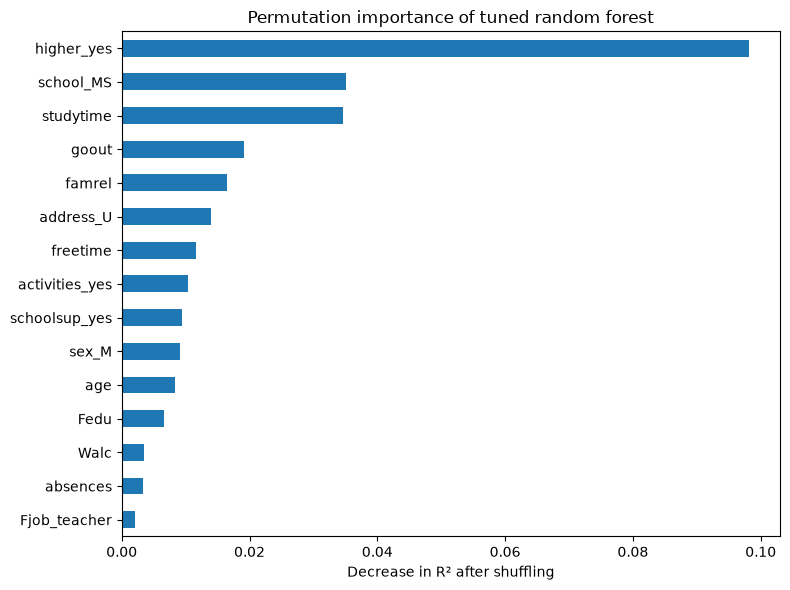

In [9]:
perm = permutation_importance(
    best_rf,
    X_test,
    y_test,
    n_repeats=20,
    random_state=42,
    scoring="r2"
)

perm_importance = pd.Series(
    perm.importances_mean,
    index=X_test.columns
).sort_values(ascending=False)

print("Top permutation importances:")
print(perm_importance.head(15))

perm_importance.head(15).sort_values().plot(
    kind="barh",
    figsize=(8, 6)
)

plt.xlabel("Decrease in R² after shuffling")
plt.title("Permutation importance of tuned random forest")
plt.tight_layout()
plt.show()

Permutation importance suggests that intention to pursue higher education is the most useful non-academic predictor in the tuned model. School, study time, going out, family relationships and address also contribute some predictive information. However, the overall model performance remains modest, so these importance values should be interpreted as predictive associations rather than causal effects.

We now compare the tuned random forest's predicted grades with the actual final grades. Points closer to the diagonal line represent more accurate predictions.

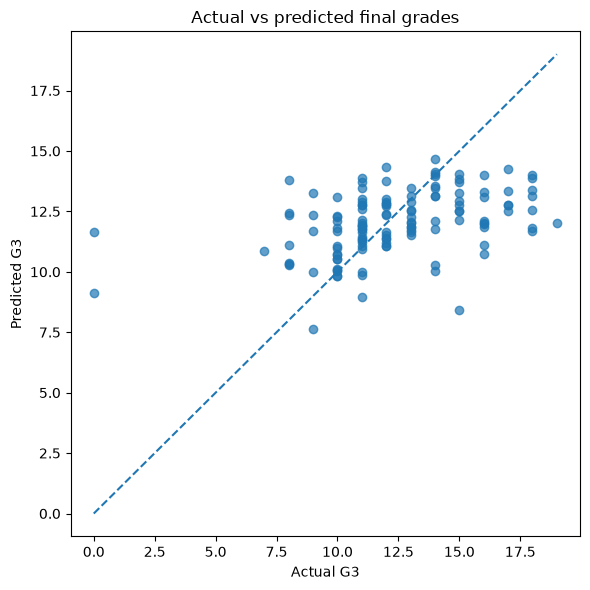

In [10]:
plt.figure(figsize=(6, 6))

plt.scatter(y_test, test_pred_best, alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)
plt.xlabel("Actual G3")
plt.ylabel("Predicted G3")
plt.title("Actual vs predicted final grades")
plt.tight_layout()
plt.show()

We look at the residuals to check whether the model systematically over- or under-predicts particular grades.

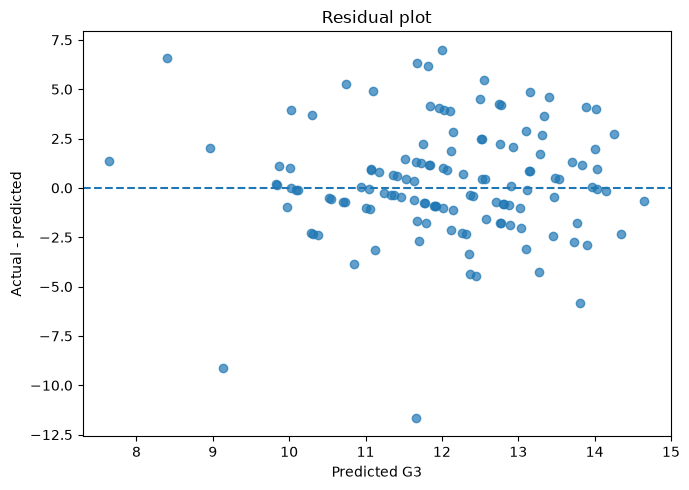

In [11]:
residuals = y_test - test_pred_best

plt.figure(figsize=(7, 5))

plt.scatter(test_pred_best, residuals, alpha=0.7)
plt.axhline(0, linestyle="--")

plt.xlabel("Predicted G3")
plt.ylabel("Actual - predicted")
plt.title("Residual plot")
plt.tight_layout()
plt.show()

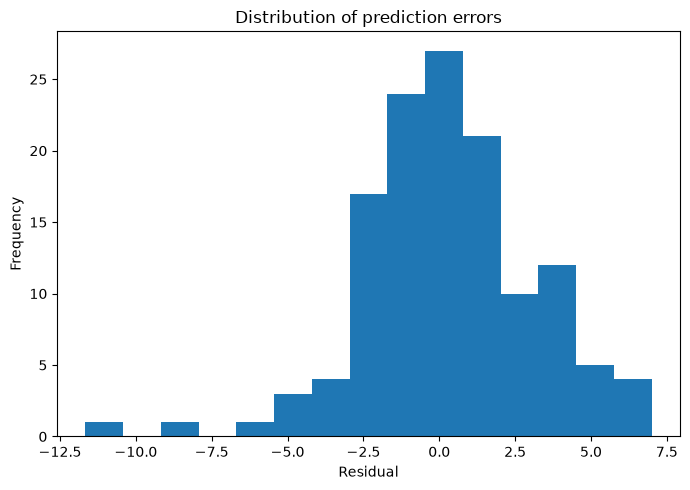

In [12]:
plt.figure(figsize=(7, 5))

plt.hist(residuals, bins=15)

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Distribution of prediction errors")
plt.tight_layout()
plt.show()

Most residuals are centred around zero, although there are still some fairly large prediction errors.

Finally, we compare the baseline, original random forest and tuned random forest on the same test set.

In [13]:
comparison = pd.DataFrame({
    "Baseline": {
        "R²": baseline_r2,
        "MAE": baseline_mae,
        "RMSE": baseline_rmse
    },
    "Random forest": {
        "R²": results_basic["Test R²"],
        "MAE": results_basic["MAE"],
        "RMSE": results_basic["RMSE"]
    },
    "Tuned random forest": {
        "R²": r2_score(y_test, test_pred_best),
        "MAE": mean_absolute_error(y_test, test_pred_best),
        "RMSE": np.sqrt(mean_squared_error(y_test, test_pred_best))
    }
}).T

comparison.round(3)

,R²,MAE,RMSE
Baseline,-0.032,2.395,3.173
Random forest,0.142,2.160,2.892
Tuned random forest,0.169,2.074,2.846


The random forest predicted final grades very accurately when previous academic performance was included, but performance dropped substantially after removing G1, G2 and previous failures. This suggests that previous academic performance contains most of the useful information for predicting G3.

Using only the remaining variables, the random forest still performed better than the baseline model, but its predictive accuracy was fairly limited. Cross-validation also showed that performance varied between different subsets of students.

Hyperparameter tuning improved the test R² slightly, but the large difference between training and test performance remained. Among the remaining predictors, intention to pursue higher education, school, study time and some behavioural variables were the most useful to the tuned model.

These results show predictive associations rather than causal relationships.